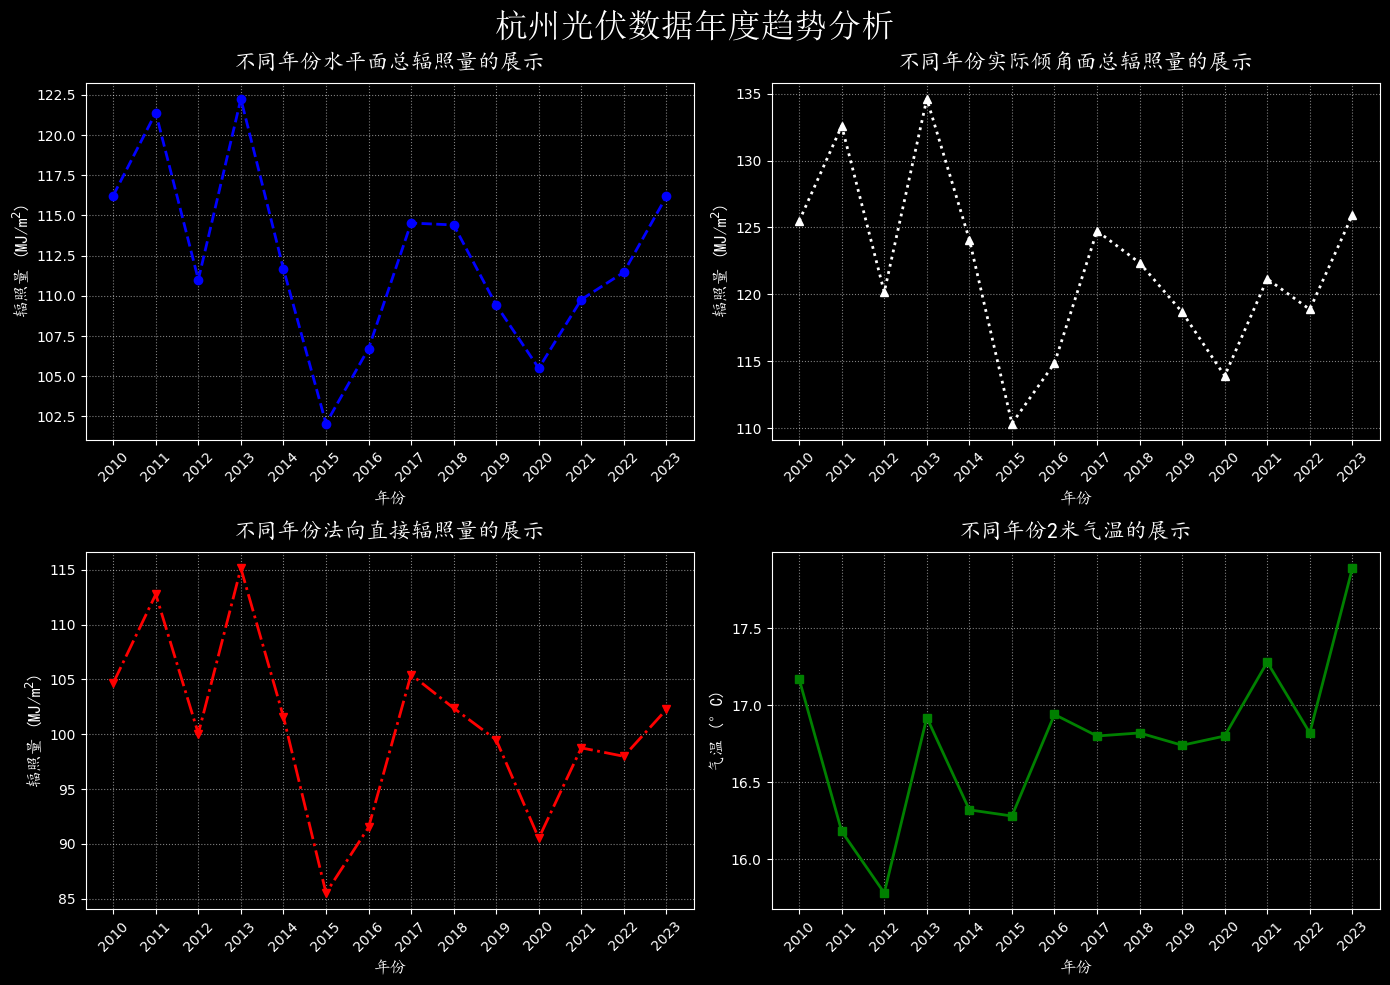

In [57]:
import pandas as pd
import matplotlib.pyplot as plt
from IPython.core.pylabtools import figsize
from fontTools.ufoLib import fontInfoOpenTypeOS2CodePageRangesOptions
from pandas.conftest import ascending
from pyparsing import alphas

df = pd.read_csv("C:\\Users\\someo\\Desktop\\杭州光伏数据MAX.csv",skiprows=6 ,sep = "\\s+",skipfooter=9,engine ='python')
df.columns = ['年份','月份','水平面总辐照量','最佳倾角面总辐照量','实际倾角面总辐照量','法向直接辐照量','2米气温']
df = df.groupby('年份')[['水平面总辐照量','实际倾角面总辐照量','法向直接辐照量','2米气温']].mean()
cols = ['水平面总辐照量','实际倾角面总辐照量','法向直接辐照量','2米气温']
df[cols] = df[cols].round(2)
df

# ... existing code ...
# 绘制图片
plt.figure(figsize=(14, 10))

# 1号图:破折线 + 圆点标记
plt.subplot(2,2,1)
plt.title('不同年份水平面总辐照量的展示',fontproperties='kaiti',fontsize=16, pad=10)
plt.plot(df.index, df['水平面总辐照量'], linestyle='--', marker='o', color='b', linewidth=2, markersize=6)
plt.xlabel('年份', fontproperties='kaiti', fontsize=12)
plt.ylabel(r'辐照量 (MJ/m$^2$)', fontproperties='kaiti', fontsize=12)
plt.xticks(df.index, rotation=45)
plt.yticks(fontsize=10)
plt.grid(True, linestyle=':', alpha=0.5)

# 2号图:虚线 + 上三角标记
plt.subplot(2,2,2)
plt.title('不同年份实际倾角面总辐照量的展示',fontproperties='kaiti',fontsize=16, pad=10)
plt.plot(df.index, df['实际倾角面总辐照量'], linestyle=':', marker='^', color='w', linewidth=2, markersize=6)
plt.xlabel('年份', fontproperties='kaiti', fontsize=12)
plt.ylabel(r'辐照量 (MJ/m$^2$)', fontproperties='kaiti', fontsize=12)
plt.xticks(df.index, rotation=45)
plt.yticks(fontsize=10)
plt.grid(True, linestyle=':', alpha=0.5)

# 3号图:点画线 + 下三角标记
plt.subplot(2,2,3)
plt.title('不同年份法向直接辐照量的展示',fontproperties='kaiti',fontsize=16, pad=10)
plt.plot(df.index, df['法向直接辐照量'], linestyle='-.', marker='v', color='r', linewidth=2, markersize=6)
plt.xlabel('年份', fontproperties='kaiti', fontsize=12)
plt.ylabel(r'辐照量 (MJ/m$^2$)', fontproperties='kaiti', fontsize=12)
plt.xticks(df.index, rotation=45)
plt.yticks(fontsize=10)
plt.grid(True, linestyle=':', alpha=0.5)

# 4号图:方形标记
plt.subplot(2,2,4)
plt.title('不同年份2米气温的展示',fontproperties='kaiti',fontsize=16, pad=10)
plt.plot(df.index, df['2米气温'], marker='s', color='g', linewidth=2, markersize=6)
plt.xlabel('年份', fontproperties='kaiti', fontsize=12)
plt.ylabel('气温 (°C)', fontproperties='kaiti', fontsize=12)
plt.xticks(df.index, rotation=45)
plt.yticks(fontsize=10)
plt.grid(True, linestyle=':', alpha=0.5)

# 添加总标题 - 放大并改为宋体
plt.suptitle('杭州光伏数据年度趋势分析', fontproperties='SimSun', fontsize=24, fontweight='bold', y=0.98)

plt.tight_layout()
plt.show()

# ... existing code ...



Text(0.5, 1.0, '电影不同评分比例')

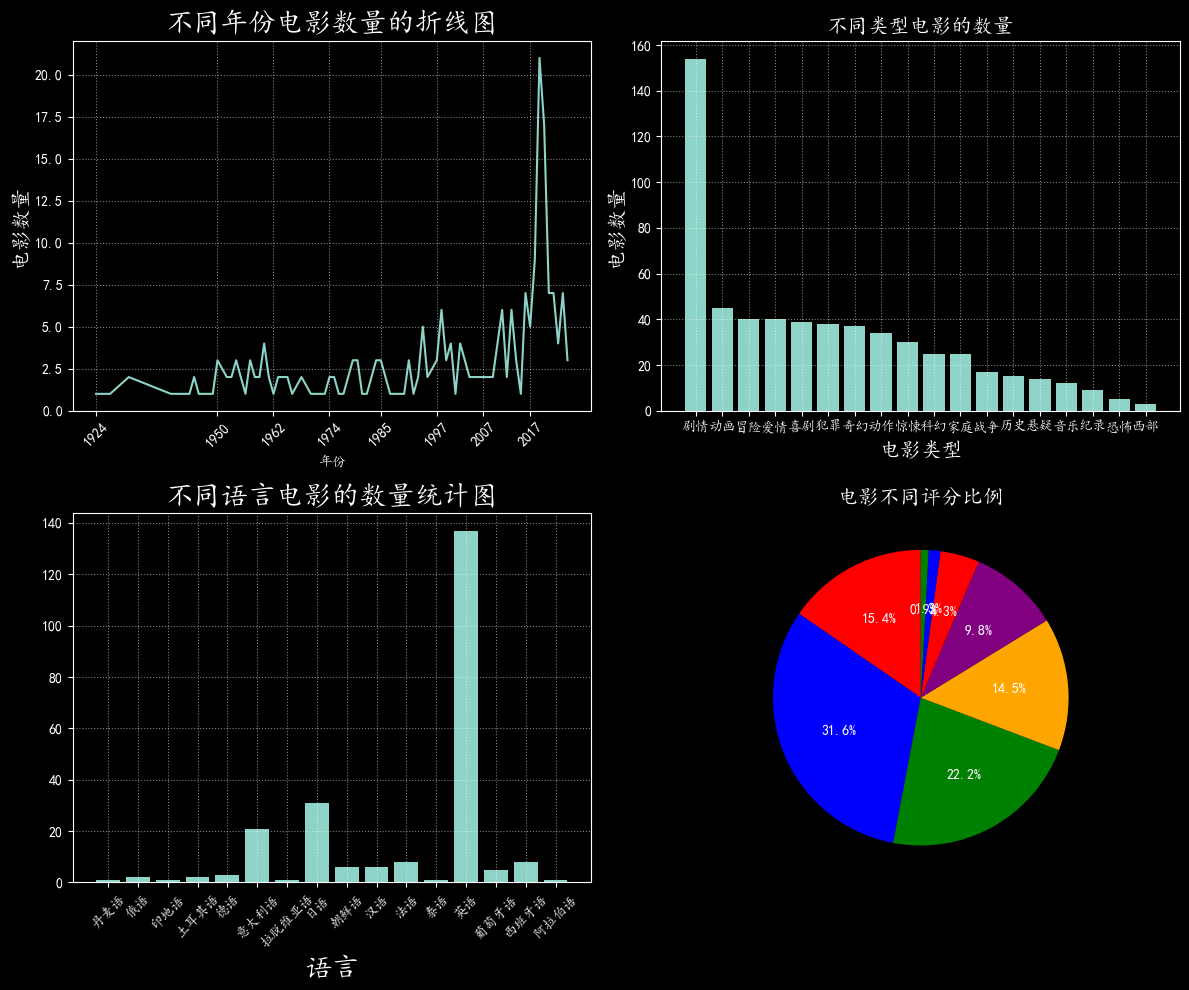

In [7]:
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.gridspec as gridspec
import numpy as np
movies_data = pd.read_csv("D:\\BaiduNetdiskDownload\\数据分析\\movies.csv",sep= ',')
#缺失值处理，直接填充上一个好像不太好，还是直接删除
#第一个图表的数据处理
movies_data = movies_data.dropna()
movies_data = movies_data.drop_duplicates(subset='电影名')
movies_data.sort_values(['年份','上映时间'],ascending=False)


# 全局设置中文字体（用你系统里有的字体）
plt.rcParams['font.family'] = 'KaiTi'
plt.rcParams['axes.unicode_minus'] = False

# 开始绘制图表
plt.figure(figsize=[12,10])
plt.subplot(2,2,1)
shu = movies_data.groupby('年份')['年份'].size()
plt.ylabel('电影数量',fontsize=15)
plt.plot(shu.index,shu)
plt.xlabel('年份',fontsize=10)
plt.xticks(shu.index[::10], rotation=45)
plt.title('不同年份电影数量的折线图',fontsize=20)
plt.grid(True,linestyle=':', alpha=0.5)

# 绘制第二份图表
#第二个图表的数据处理
language = movies_data.groupby('语言')['语言'].size()
plt.subplot(2,2,3)
plt.title('不同语言电影的数量统计图',fontsize=20)
plt.bar(language.index[::1],language)
plt.xticks(rotation=45)
plt.xlabel('语言',fontsize=20)
plt.grid(True,linestyle=':',alpha=0.5)


# 绘制第三个图表：统计不同类型电影的数量
# 1. 去除空格，按逗号拆分成列表
types_series = movies_data['类型'].str.replace(' ', '').str.split(',')

# 2. 展开成多行
types_exploded = movies_data.assign(类型=types_series).explode('类型')

# 3. 统计每个类型的数量
type_counts = types_exploded['类型'].value_counts()
plt.subplot(2,2,2)
plt.title('不同类型电影的数量',fontsize=15)
plt.bar(type_counts.index,type_counts.values)
plt.xlabel('电影类型',fontsize=15)
plt.ylabel('电影数量',fontsize=15)
plt.tight_layout()
plt.grid(True,linestyle=':',alpha=0.5)


# 第四个图表绘制，统计对比各个电影的评分比例（饼状图）
bin = movies_data.groupby('评分')['评分'].count()
# 绘制饼图
plt.subplot(2,2,4)
plt.pie(bin.values, autopct='%1.1f%%',shadow=False,startangle=90,colors=['red', 'blue', 'green', 'orange', 'purple'])
plt.title('电影不同评分比例',fontsize=15)




<Figure size 1200x1100 with 0 Axes>

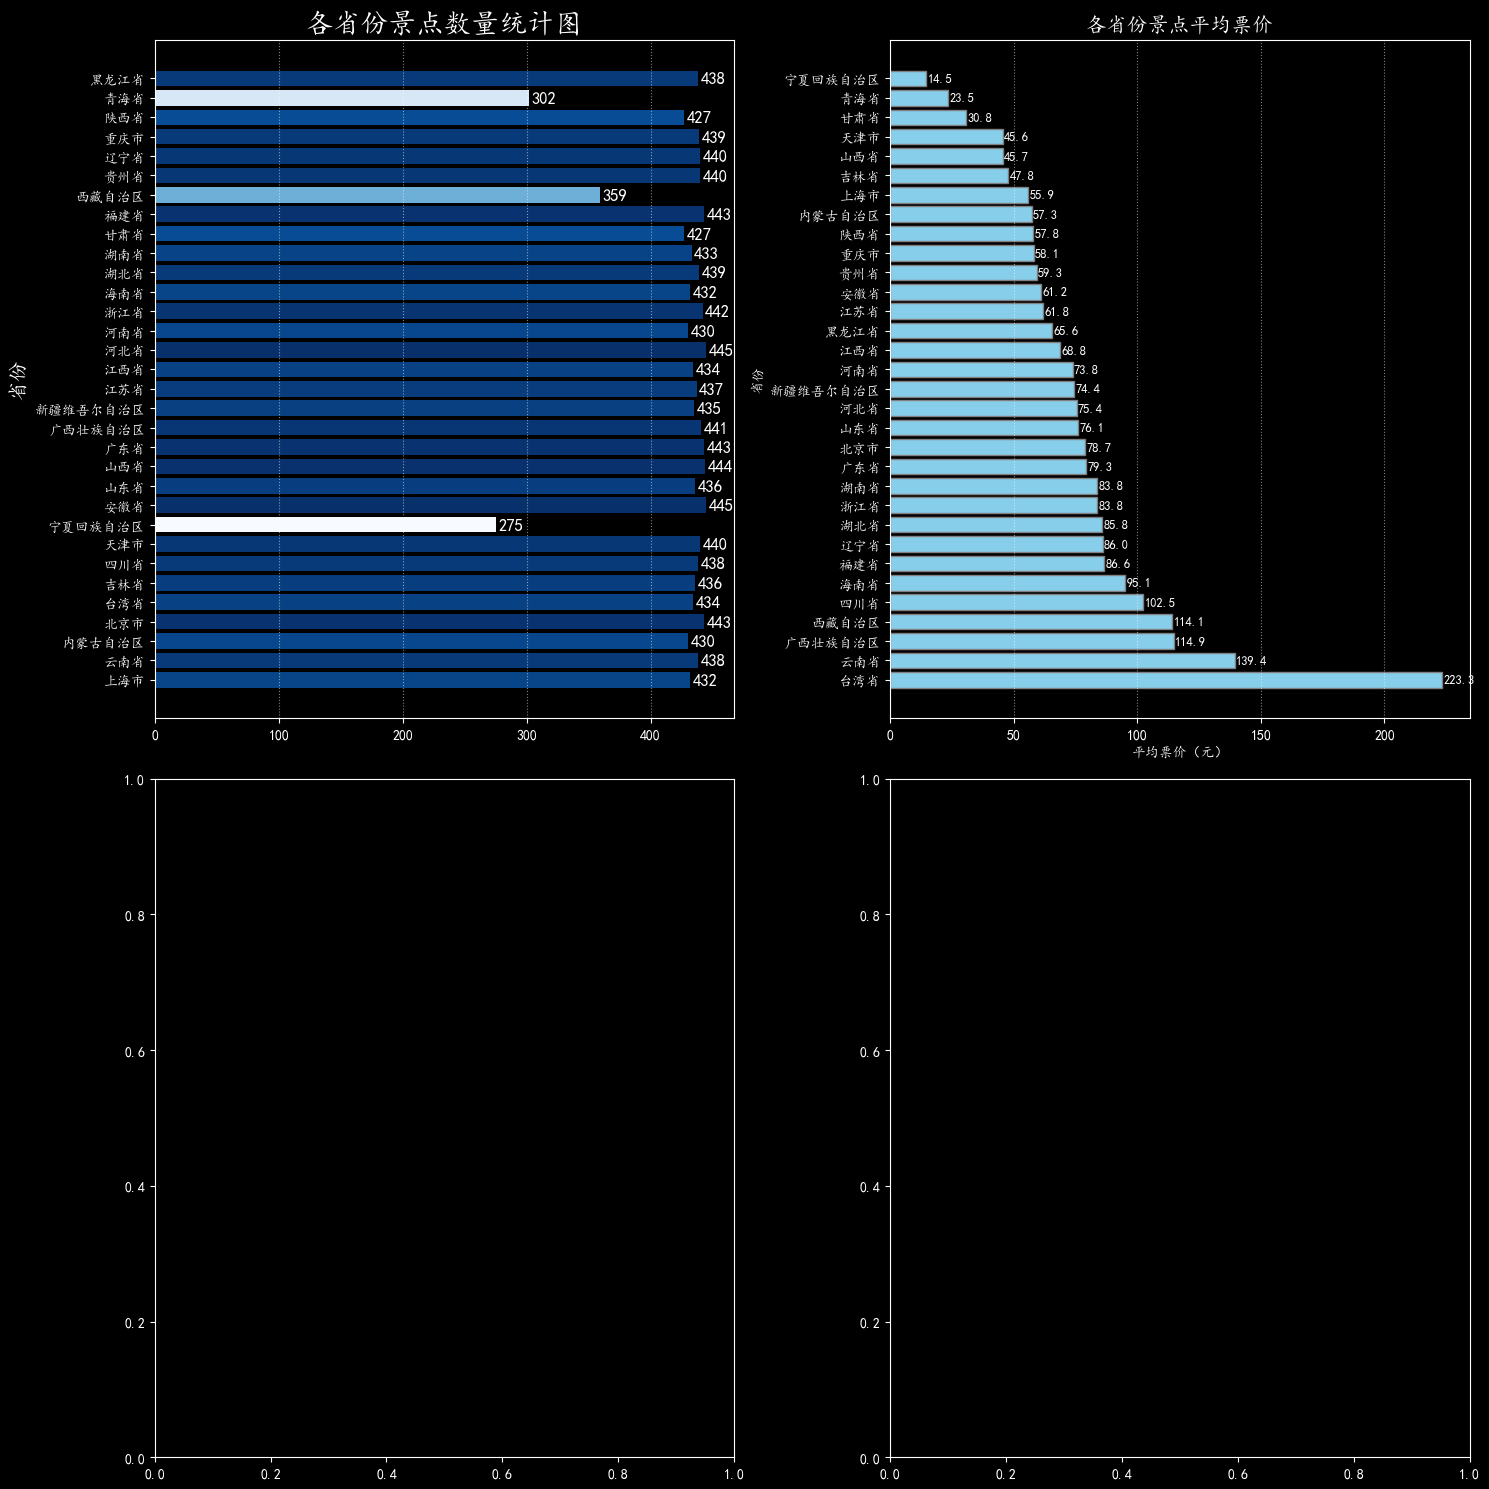

In [4]:
from matplotlib import cm
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
# 全局设置中文
plt.rcParams['font.family'] = 'KaiTi'
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 100
plt.figure(figsize=[12,11])

def read_data():
    #加载数据
    data = pd.read_csv("D:\\浏览器下载\\Edg\\数据集\\景点数据.csv",sep=',')
    #清洗数据
    data = data.dropna()
    # 查看是否有景点重复
    data = data.drop_duplicates(subset=['name'])
    # 删除数量这一列
    data = data.drop(columns='number')
    data = data.drop(columns='score')
    # 重新书写行索引，改成中文
    data.columns = ['景点名','等级', '地址', '宣传标语', '价格', '销售总额', '所在省份', '具体地区']

    # 按照地区，还有评分等级进行排序
    data = data.sort_values(by='所在省份', ascending=True)
    #查看数据总量
    return data

# 统计各省份旅游景点的数量---------直方图
def see_data(data,ax):
    province= data.groupby('所在省份')['所在省份'].size()
    # 设置颜色
    n = len(province)


    norm = plt.Normalize(province.values.min(), province.values.max())
    colors = cm.Blues(norm(province.values))
    bars = ax.barh(province.index, province.values, color=colors, edgecolor='none')
    ax.set_title('各省份景点数量统计图',fontsize=20,fontweight='bold')
    ax.set_ylabel('省份',fontsize= 15)
    ax.grid(True, linestyle=':', alpha=0.5, axis='x')
    #增加数值标签
    for i in bars:
        width = i.get_width()
        ax.text(width + 2.0, i.get_y() + i.get_height()/2,
                f'{int(width)}', va='center', fontsize=12,color='w')
    return


def see_province(data):
    """
    查询某个省份的所有景点
    """
    provinces = data['所在省份'].unique()
    while True:
        want = input('请输入你想查询的省份（支持部分名称）：').strip()
        matched = [p for p in provinces if want in p]
        # 遍历 provinces 这个列表中的每个省份名称 p，检查 want（用户输入）是否作为子串出现在 p 中。如果出现，就把 p 添加到新的列表 matched 中。
        if len(matched) == 0:
            print('未找到匹配的省份')
        elif len(matched) > 1:
            print(f'找到多个匹配：{matched}，请更精确输入')
        else:
            real_name = matched[0]
            break
    province_data = data[data['所在省份'] == real_name]
    # 显示结果
    if province_data.empty:
        print(f'没有找到 {want} 的景点数据')
    else:
        print(f'\n{want} 的景点列表（共 {len(province_data)} 个）：')
        for idx, row in province_data.iterrows():
            print(f"  {row['景点名']}")

    return province_data   # 如果需要后续处理可以返回

def plot_price(data,ax):
    # 将价格列转为数值（无法转换的变成 NaN）
    data['价格'] = pd.to_numeric(data['价格'], errors='coerce')

    # 按省份计算平均票价，并降序排列（票价高的在上）
    avg_price = data.groupby('所在省份')['价格'].mean().sort_values(ascending=False)

    # 绘制水平条形图
    bars = ax.barh(avg_price.index, avg_price.values, color='skyblue', edgecolor='gray')

    # 在每个条形末尾添加数值标签（保留一位小数）
    for bar in bars:
        width = bar.get_width()
        ax.text(width + 0.5, bar.get_y() + bar.get_height()/2,
                 f'{width:.1f}', va='center', fontsize=9)

    ax.set_title('各省份景点平均票价', fontsize=15)
    ax.set_xlabel('平均票价（元）')
    ax.set_ylabel('省份')
    ax.grid(axis='x', linestyle=':', alpha=0.5)


#-------------------------------------测试---------------------------------------------
data = read_data()
fig , ax = plt.subplots(2,2,figsize=[15,15])
see_data(data,ax[0,0])
# see_province(data)
plot_price(data,ax[0,1])
plt.tight_layout()
plt.show()